# Emergency Department Patient Count Forecasting
Cross-validation and 14/30-day forecasts using StatsForecast, MLForecast, and NeuralForecast.

## 1. Setup & Data Loading

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utilsforecast.losses import mae, rmse, smape
from utilsforecast.evaluation import evaluate

# Load data
df_raw = pd.read_csv("patient_counts.csv", parse_dates=["date"])

# Nixtla libraries expect: unique_id, ds, y
df = df_raw.rename(columns={"date": "ds", "num_patients": "y"})
df["unique_id"] = "acil_servis"
df = df[["unique_id", "ds", "y"]].sort_values("ds").reset_index(drop=True)

print(f"Date range : {df['ds'].min().date()} → {df['ds'].max().date()}")
print(f"Total days : {len(df)}")
print(f"Missing days: {pd.date_range(df['ds'].min(), df['ds'].max()).difference(df['ds']).size}")
df.tail()

Date range : 2022-01-10 → 2025-12-31
Total days : 1452
Missing days: 0


,unique_id,ds,y
1447,acil_servis,2025-12-27,1538
1448,acil_servis,2025-12-28,1763
1449,acil_servis,2025-12-29,1806
1450,acil_servis,2025-12-30,1671
1451,acil_servis,2025-12-31,1485


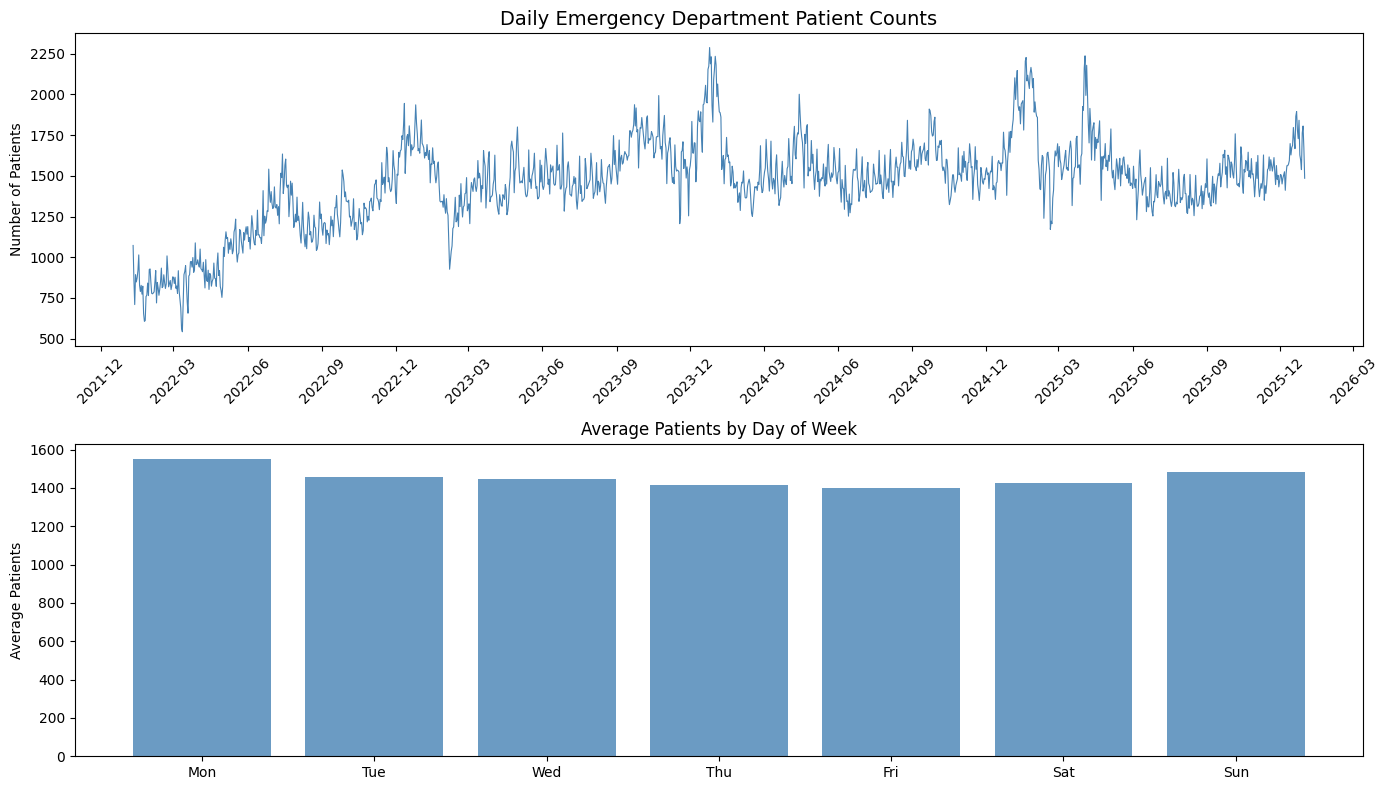

In [2]:
# Quick look at the time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df["ds"], df["y"], linewidth=0.8, color="steelblue")
axes[0].set_title("Daily Emergency Department Patient Counts", fontsize=14)
axes[0].set_ylabel("Number of Patients")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Weekly pattern
df["dow"] = df["ds"].dt.dayofweek
axes[1].bar(range(7), df.groupby("dow")["y"].mean(), color="steelblue", alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("Average Patients by Day of Week")
axes[1].set_ylabel("Average Patients")

plt.tight_layout()
plt.show()

In [3]:
def evaluate_metrics(df):
    metrics = []
    model_cols = [
        col
        for col in df.columns
        if col not in ["unique_id", "ds", "cutoff", "y"] and not col.endswith("_smape") and not col.endswith("_mape")
    ]

    # Calculate metrics for each model
    for metric in ["mae", "rmse", "smape"]:
        row = {"metric": metric}
        for model in model_cols:
            if metric == "mae":
                value = (df[model] - df["y"]).abs().mean()
            elif metric == "rmse":
                value = ((df[model] - df["y"]) ** 2).mean() ** 0.5
            elif metric == "smape":
                smape = (abs(df[model] - df["y"]) / ((df["y"].abs() + df[model].abs()) / 2)).fillna(0)
                value = smape.mean()
            row[model] = value
        metrics.append(row)

    return pd.DataFrame(metrics)

## 2. StatsForecast — Naive, SeasonalNaive, WindowAverage, AutoARIMA

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, WindowAverage, AutoARIMA

SEASON_LENGTH = 7  # weekly seasonality
CV_N_WINDOWS = 4  # number of cross-validation folds
STEP_SIZE = 14  # step between folds

sf_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON_LENGTH),
    WindowAverage(window_size=7),
    AutoARIMA(season_length=SEASON_LENGTH),
]

sf = StatsForecast(models=sf_models, freq="D", n_jobs=-1, verbose=True)

# ---- Cross-validation (14-day horizon) ----
sf_cv14 = sf.cross_validation(df=df, h=14, n_windows=CV_N_WINDOWS, step_size=STEP_SIZE)
print("StatsForecast CV (h=14) done. Shape:", sf_cv14.shape)
sf_cv14.head()

Cross Validation Time Series 1: 100%|██████████| 4/4 [00:14<00:00,  3.54s/it]

StatsForecast CV (h=14) done. Shape: (56, 8)


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,WindowAverage,AutoARIMA
0,acil_servis,2025-11-06,2025-11-05,1417.0,1372.0,1371.0,1474.285767,1380.751221
1,acil_servis,2025-11-07,2025-11-05,1452.0,1372.0,1454.0,1474.285767,1409.490112
2,acil_servis,2025-11-08,2025-11-05,1423.0,1372.0,1584.0,1474.285767,1438.679199
3,acil_servis,2025-11-09,2025-11-05,1474.0,1372.0,1484.0,1474.285767,1417.289185
4,acil_servis,2025-11-10,2025-11-05,1628.0,1372.0,1625.0,1474.285767,1502.523926


In [5]:
# ---- Cross-validation (30-day horizon) ----
sf_cv30 = sf.cross_validation(df=df, h=30, n_windows=CV_N_WINDOWS, step_size=STEP_SIZE)
print("StatsForecast CV (h=30) done. Shape:", sf_cv30.shape)

# Evaluate
sf_model_cols = [m.__class__.__name__ for m in sf_models]
# AutoARIMA column may appear as just 'AutoARIMA'
sf_model_cols_actual = [c for c in sf_cv14.columns if c not in ["unique_id", "ds", "cutoff", "y"]]
print("Model columns:", sf_model_cols_actual)

sf_eval14 = evaluate_metrics(sf_cv14)
sf_eval30 = evaluate_metrics(sf_cv30)

print("\n=== StatsForecast — h=14 ===")
display(sf_eval14)
print("\n=== StatsForecast — h=30 ===")
display(sf_eval30)

Cross Validation Time Series 1: 100%|██████████| 4/4 [00:14<00:00,  3.52s/it]

StatsForecast CV (h=30) done. Shape: (120, 8)
Model columns: ['Naive', 'SeasonalNaive', 'WindowAverage', 'AutoARIMA']

=== StatsForecast — h=14 ===


,metric,Naive,SeasonalNaive,WindowAverage,AutoARIMA
0,mae,117.071426,94.607140,85.469376,94.094368
1,rmse,141.897720,123.462257,109.444695,118.075844
2,smape,0.075132,0.060131,0.054037,0.059968



=== StatsForecast — h=30 ===


,metric,Naive,SeasonalNaive,WindowAverage,AutoARIMA
0,mae,117.608330,108.449997,94.751198,94.443916
1,rmse,143.229385,141.697449,127.840858,127.302963
2,smape,0.075196,0.070344,0.061015,0.060756


## 3. MLForecast — LightGBM & XGBoost

In [6]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from numba import njit
from window_ops.rolling import rolling_mean


@njit
def rolling_mean_7(x):
    return rolling_mean(x, window_size=7)


@njit
def rolling_mean_14(x):
    return rolling_mean(x, window_size=14)


@njit
def rolling_mean_30(x):
    return rolling_mean(x, window_size=30)


ml_models = [
    LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbosity=0),
]

mlf = MLForecast(
    models=ml_models,
    freq="D",
    lags=[1, 7, 14, 21, 28],
    lag_transforms={
        1: [rolling_mean_7],
        7: [rolling_mean_14],
        14: [rolling_mean_30],
    },
    date_features=["dayofweek", "month", "quarter"],
    target_transforms=[Differences([1])],
)

# ---- Cross-validation (14-day horizon) ----
mlf_cv14 = mlf.cross_validation(df=df, h=14, n_windows=CV_N_WINDOWS, static_features=[], step_size=STEP_SIZE)
print("MLForecast CV (h=14) done. Shape:", mlf_cv14.shape)

# ---- Cross-validation (30-day horizon) ----
mlf_cv30 = mlf.cross_validation(df=df, h=30, n_windows=CV_N_WINDOWS, static_features=[], step_size=STEP_SIZE)
print("MLForecast CV (h=30) done. Shape:", mlf_cv30.shape)

mlf_eval14 = evaluate_metrics(mlf_cv14)
mlf_eval30 = evaluate_metrics(mlf_cv30)

print("\n=== MLForecast — h=14 ===")
display(mlf_eval14)
print("\n=== MLForecast — h=30 ===")
display(mlf_eval30)

MLForecast CV (h=14) done. Shape: (56, 6)
MLForecast CV (h=30) done. Shape: (120, 6)

=== MLForecast — h=14 ===


,metric,LGBMRegressor,XGBRegressor
0,mae,63.038594,84.855541
1,rmse,80.416913,106.277974
2,smape,0.040207,0.053464



=== MLForecast — h=30 ===


,metric,LGBMRegressor,XGBRegressor
0,mae,94.023237,81.611542
1,rmse,118.710331,100.293987
2,smape,0.061290,0.052757


## 4. NeuralForecast — NBEATS, NHITS, PatchTST

In [7]:
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

INPUT_SIZE = 14  # look-back window (2 weeks — shorter = faster)
MAX_STEPS = 50  # reduced from 100
NF_N_WINDOWS = 2  # fewer CV folds for neural models (expensive to train)


def build_nf(horizon):
    return NeuralForecast(
        models=[
            PatchTST(
                h=horizon,
                input_size=INPUT_SIZE,
                max_steps=MAX_STEPS,
                scaler_type="standard",
                patch_len=7,
                stride=7,
                early_stop_patience_steps=5,
                val_check_steps=10,
            ),
        ],
        freq="D",
    )


# ---- Cross-validation (h=14) ----
nf14 = build_nf(14)
nf_cv14 = nf14.cross_validation(df=df, n_windows=NF_N_WINDOWS, step_size=STEP_SIZE, val_size=14)
print("NeuralForecast CV (h=14) done. Shape:", nf_cv14.shape)
nf_cv14.head()

2026-04-07 20:46:55,393	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-07 20:46:55,515	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss         | MAE               | 0      | train | 0    
1 | padder_train | ConstantPad1d     | 0      | train | 0    
2 | scaler       | TemporalNorm      | 0      | train | 0    
3 | model        | P

Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 25.47it/s, v_num=8, train_loss_step=1.170, train_loss_epoch=1.170, valid_loss=71.80]

`Trainer.fit` stopped: `max_steps=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 24.73it/s, v_num=8, train_loss_step=1.170, train_loss_epoch=1.170, valid_loss=71.80]


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 18.19it/s]
NeuralForecast CV (h=14) done. Shape: (28, 5)


,unique_id,ds,cutoff,PatchTST,y
0,acil_servis,2025-12-04,2025-12-03,1460.297974,1485
1,acil_servis,2025-12-05,2025-12-03,1469.447754,1504
2,acil_servis,2025-12-06,2025-12-03,1468.097656,1525
3,acil_servis,2025-12-07,2025-12-03,1472.566284,1411
4,acil_servis,2025-12-08,2025-12-03,1481.341675,1512


In [8]:
# ---- Cross-validation (h=30) ----
nf30 = build_nf(30)
nf_cv30 = nf30.cross_validation(df=df, n_windows=NF_N_WINDOWS, step_size=STEP_SIZE, val_size=30)
print("NeuralForecast CV (h=30) done. Shape:", nf_cv30.shape)

nf_eval14 = evaluate_metrics(nf_cv14)
nf_eval30 = evaluate_metrics(nf_cv30)

print("\n=== NeuralForecast — h=14 ===")
display(nf_eval14)
print("\n=== NeuralForecast — h=30 ===")
display(nf_eval30)

Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss         | MAE               | 0      | train | 0    
1 | padder_train | ConstantPad1d     | 0      | train | 0    
2 | scaler       | TemporalNorm      | 0      | train | 0    
3 | model        | PatchTST_backbone | 410 K  | train | 0    
-------------------------------------------------------------------
410 K     Trainable params
3         Non-trainable params
410 K     Total params
1.642     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 25.32it/s, v_num=10, train_loss_step=1.480, train_loss_epoch=1.480, valid_loss=66.20]

`Trainer.fit` stopped: `max_steps=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00, 24.58it/s, v_num=10, train_loss_step=1.480, train_loss_epoch=1.480, valid_loss=66.20]


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 54.40it/s]
NeuralForecast CV (h=30) done. Shape: (60, 5)

=== NeuralForecast — h=14 ===


,metric,PatchTST
0,mae,114.121726
1,rmse,138.816755
2,smape,0.070145



=== NeuralForecast — h=30 ===


,metric,PatchTST
0,mae,112.632086
1,rmse,148.064730
2,smape,0.070662


## 5. Combined Evaluation Summary

In [9]:
def eval_to_long(df_eval, library):
    model_cols = [c for c in df_eval.columns if c not in ["unique_id", "metric"]]
    melted = df_eval.melt(id_vars="metric", value_vars=model_cols, var_name="model", value_name="value")
    melted.insert(0, "library", library)
    return melted


def make_summary(evals14, evals30, labels):
    def pivot(frames):
        long = pd.concat(frames, ignore_index=True)
        return (
            long.pivot_table(index=["library", "model"], columns="metric", values="value")
            .reset_index()
            .rename_axis(None, axis=1)
        )

    frames14 = [eval_to_long(e, l) for e, l in zip(evals14, labels)]
    frames30 = [eval_to_long(e, l) for e, l in zip(evals30, labels)]
    return pivot(frames14), pivot(frames30)


summary14, summary30 = make_summary(
    [sf_eval14, mlf_eval14, nf_eval14],
    [sf_eval30, mlf_eval30, nf_eval30],
    ["StatsForecast", "MLForecast", "NeuralForecast"],
)

print("=== ALL MODELS — h=14 ===")
display(summary14.sort_values("smape"))
print("=== ALL MODELS — h=30 ===")
display(summary30.sort_values("smape"))

=== ALL MODELS — h=14 ===


,library,model,mae,rmse,smape
0,MLForecast,LGBMRegressor,63.038594,80.416913,0.040207
1,MLForecast,XGBRegressor,84.855541,106.277974,0.053464
6,StatsForecast,WindowAverage,85.469376,109.444695,0.054037
3,StatsForecast,AutoARIMA,94.094368,118.075844,0.059968
5,StatsForecast,SeasonalNaive,94.607140,123.462257,0.060131
2,NeuralForecast,PatchTST,114.121726,138.816755,0.070145
4,StatsForecast,Naive,117.071426,141.897720,0.075132


=== ALL MODELS — h=30 ===


,library,model,mae,rmse,smape
1,MLForecast,XGBRegressor,81.611542,100.293987,0.052757
3,StatsForecast,AutoARIMA,94.443916,127.302963,0.060756
6,StatsForecast,WindowAverage,94.751198,127.840858,0.061015
0,MLForecast,LGBMRegressor,94.023237,118.710331,0.061290
5,StatsForecast,SeasonalNaive,108.449997,141.697449,0.070344
2,NeuralForecast,PatchTST,112.632086,148.064730,0.070662
4,StatsForecast,Naive,117.608330,143.229385,0.075196


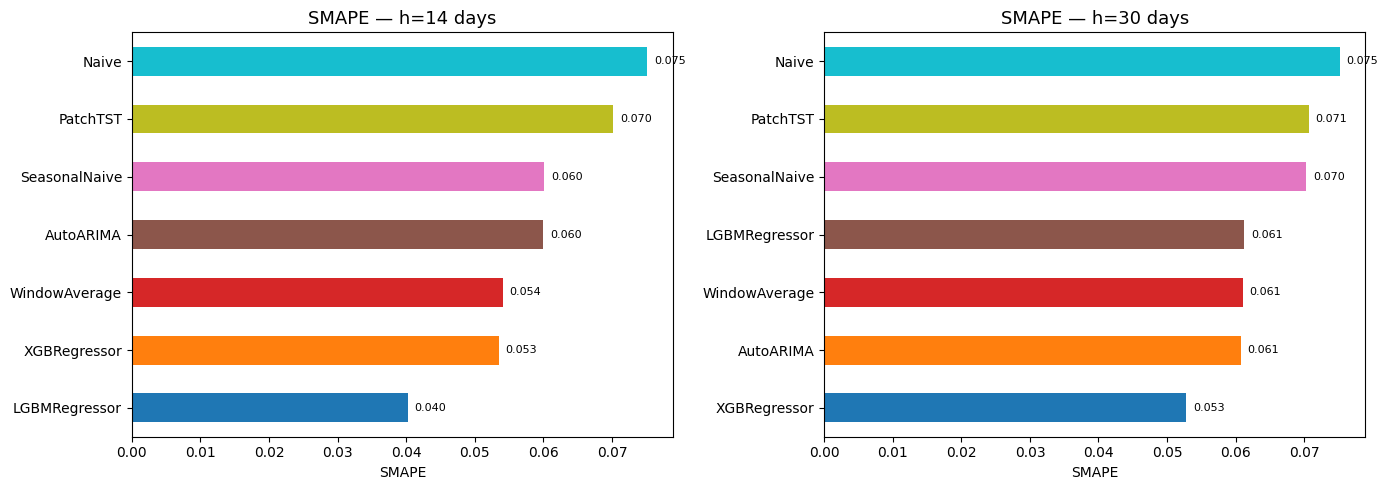

In [10]:
# Visualise SMAPE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summary, title in [
    (axes[0], summary14, "h=14 days"),
    (axes[1], summary30, "h=30 days"),
]:
    pivot = summary.set_index("model")["smape"].sort_values()
    colors = plt.cm.tab10(np.linspace(0, 1, len(pivot)))
    pivot.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(f"SMAPE — {title}", fontsize=13)
    ax.set_xlabel("SMAPE")
    ax.set_ylabel("")
    for bar in ax.patches:
        ax.text(
            bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.3f}", va="center", fontsize=8
        )

plt.tight_layout()
plt.show()